# Deney günlüğü — ne denedik, ne çıktı, ne karar verdik

Bu defter **yolculuğun tamamıdır**: ilk ölçümden bugüne kadar denenen her şey
sırayla. Her adım aynı düzende:

> **Ne denedik** → **Sonuç** → **Karar** → **Çıkarım** (bir sonraki adımı bu doğurdu)

Kabul edilen sistemin adım adım defteri ayrı:
`KABUL-1_AAPL_takip_eden_stop.ipynb`. Yazılı kayıt: `hypotheses/REGISTRY.md`
(tüm sonuç tabloları orada).

Eski defterler (`h001_measure`, `h001_daily`, `h001_hourly`,
`h001_backtest`) içerikleri bu iki deftere toplandıktan sonra kullanıcı
kararıyla kaldırıldı; git geçmişinde (commit `931355d`) duruyorlar.

**Veri:** 2016-01 → 2024-06. 2024-07 sonrası saklanan veri (kasa) hiç açılmadı.
**Maliyet:** her alışta ve her satışta %0.05.

**Hesaplar:** günlük veriyle yapılan her şey bu defterde yeniden hesaplanır.
Saatlik takip eden stop ve dakikalık hesaplar dakikalar sürdüğü için kayıttan
okunur; her birinin kaynağı yazılıdır.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd

from src.data.load import load_bars
from lab.session import regular_hours
from lab.splits import split_research_vault
from lab import h001, analysis, plots
from lab import backtest as bt
from lab.backtest import Kurallar, calistir, ozet, egitim_test, egitim_test_detay, zincirle, al_tut

pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

MALIYET = 0.0005
TEST_YILLARI = range(2019, 2025)


def arastirma(sembol, frekans):
    # saklanan veri (kasa) burada ayrılır ve hiç kullanılmaz
    df = load_bars(sembol, frekans)
    if frekans == '1Hour':
        df = regular_hours(df)          # sadece borsa saatleri
    return split_research_vault(df, horizon_bars=1).research


SPY_G, SPY_S = arastirma('SPY', '1Day'), arastirma('SPY', '1Hour')
AAPL_G, AAPL_S = arastirma('AAPL', '1Day'), arastirma('AAPL', '1Hour')


def calis(veri, n, **kural):
    return calistir(veri, Kurallar(n=n, maliyet=MALIYET, **kural))


def lira(sonuc):
    return float(sonuc.bakiye.iloc[-1])


print(f'SPY günlük {len(SPY_G)} bar, saatlik {len(SPY_S)} bar | '
      f'AAPL günlük {len(AAPL_G)} bar, saatlik {len(AAPL_S)} bar')
print(f"dönem: {SPY_G['timestamp'].iloc[0].date()} → {SPY_G['timestamp'].iloc[-1].date()}")

SPY günlük 2135 bar, saatlik 14951 bar | AAPL günlük 2135 bar, saatlik 14939 bar
dönem: 2016-01-04 → 2024-06-27


---
## Adım 1 — Önce ölçtük: fiyat dipteyken ertesi gün daha mı çok yükseliyor?

**Ne denedik.** Hiç al-sat yapmadan, sadece ölçüm. Fiyatın son N günün kanalı
içindeki yerini (0 = dip, 1 = tepe) ertesi günün getirisiyle karşılaştırdık.
İddia doğruysa dipte yüksek getiri, tepede düşük getiri görülmeli, yani sıra
korelasyonu (rho) **negatif** olmalı.

**Kriter önceden yazıldı:** rho negatif olacak, `p < 0.05 / 6` ve `|rho| ≥ 0.05`.
Altı ölçüm yapıldığı için p eşiği altıya bölündü; şans eseri bir tanesinin
"anlamlı" çıkmasını engellemek için.

,veri,çizgi (gün),rho,p,kriteri geçti mi
0,SPY günlük,20,-0.041,0.062,hayır
1,SPY günlük,50,-0.048,0.030,hayır
2,SPY günlük,100,-0.038,0.084,hayır
3,SPY saatlik,20,-0.036,0.098,hayır
4,SPY saatlik,50,-0.043,0.048,hayır
5,SPY saatlik,100,-0.038,0.090,hayır


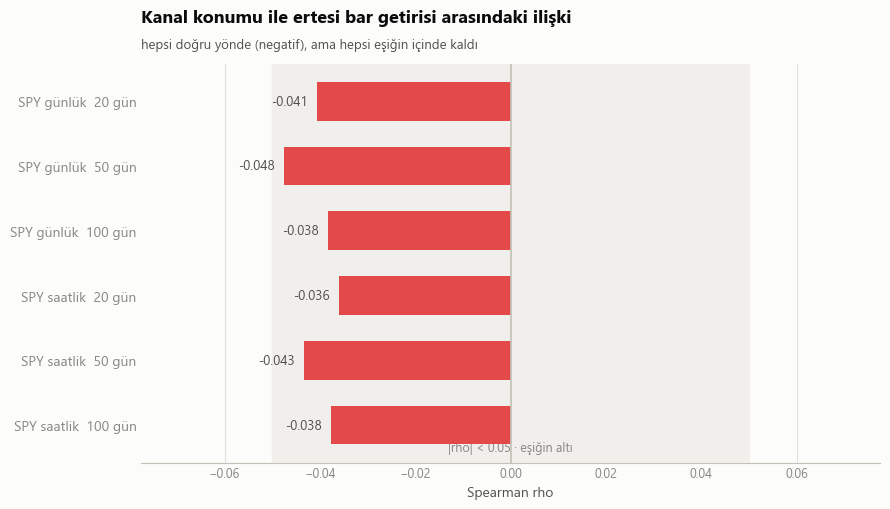

In [2]:
satirlar = []
for ad, veri, k in (('SPY günlük', SPY_G, 1), ('SPY saatlik', SPY_S, 7)):
    for gun in (20, 50, 100):
        n = gun if k == 1 else gun * 7
        r = analysis.rank_correlation(h001.channel_position(veri, n),
                                      h001.forward_return(veri, k), horizon_bars=k)
        satirlar.append({'veri': ad, 'çizgi (gün)': gun, 'rho': r.rho, 'p': r.p_value,
                         'kriteri geçti mi':
                             'evet' if (r.rho < 0 and r.p_value < 0.05 / 6
                                        and abs(r.rho) >= 0.05) else 'hayır'})
olcum = pd.DataFrame(satirlar)
display(olcum)
plots.rho_chart(olcum['veri'] + '  ' + olcum['çizgi (gün)'].astype(str) + ' gün',
                olcum['rho'], min_rho=0.05,
                title='Kanal konumu ile ertesi bar getirisi arasındaki ilişki',
                subtitle='hepsi doğru yönde (negatif), ama hepsi eşiğin içinde kaldı');

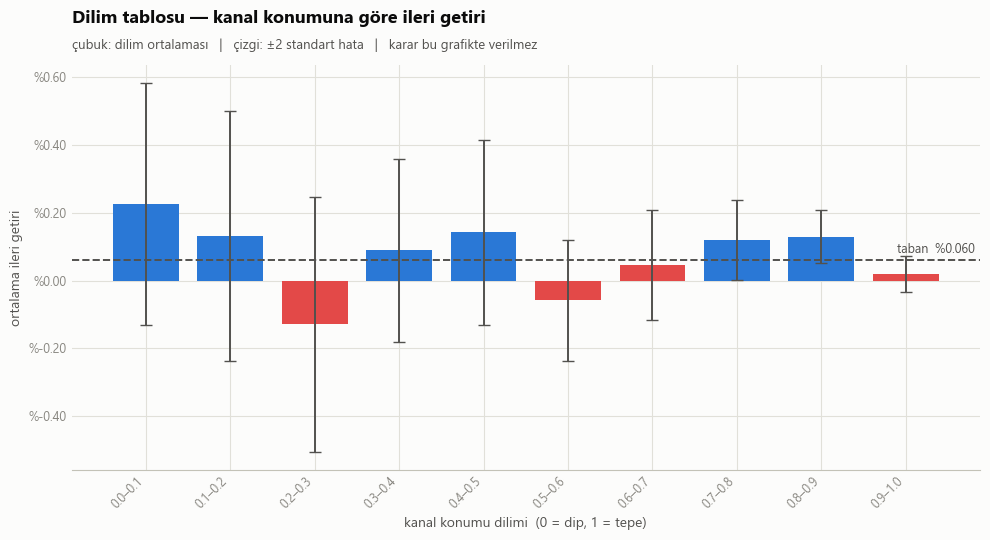

In [3]:
# Dilimlere ayırınca ne görünüyor: kanal konumunun her diliminde ortalama getiri
x = h001.channel_position(SPY_G, 20)
y = h001.forward_return(SPY_G, 1)
plots.bin_chart(analysis.bin_table(x, y, n_bins=10), reference=float(y.mean()),
                );

**Sonuç.** İşaret doğru yönde (hepsi negatif) ama etki ilan edilen eşiğin
altında: SPY günlük 20 gün için rho −0.041, p 0.067. Dilim grafiğinde de
çubukların hata payları birbirini örtüyor, yani eğim gürültüden ayrılmıyor.

**Karar: H-001 REDDEDİLDİ** (günlük ve saatlik).

**Çıkarım.** Ölçüm zayıf çıktı, ama kullanıcının istediği şey zaten bir ölçüm
değil, **al-sat sistemi**: dipte al, tepede sat, dibin çok altına inerse zararı
kes. Sıradaki adım bu sistemi kurup parayla denemek.

---
## Adım 2 — Sistemi kurduk: 1 haftalık çizgilerle al-sat

**Ne denedik.** Kullanıcının anlattığı sistem: son 1 haftanın en yükseği
(direnç) ve en düşüğü (destek). Fiyat dibe yaklaşınca al, tepeye değince sat,
dibin epey altına inerse zararına sat. Günlükte 5 bar, saatlikte 35 bar.

Eşikleri ben seçtim: alım = dipten kanal genişliğinin %10'u yukarısı,
zararına satış = dipten yarım genişlik aşağısı.

**Karşılaştırma tabanı (baseline):** başta al, sonda sat. Hiçbir şey yapmamak.

,SPY günlük sistem,SPY saatlik sistem,başta al sonda sat
toplam getiri,0.027,0.110,2.116
toplam getiri (maliyetsiz),0.301,0.464,2.116
yıllık getiri,0.003,0.012,0.144
en büyük düşüş,-0.314,-0.450,-0.338
piyasada kalma süresi,0.301,0.393,1.000
işlem sayısı,237.000,277.000,1.000
kazanan işlem oranı,0.481,0.509,NaN
ortalama işlem getirisi,0.000,0.001,NaN
tepede satılan,114.000,141.000,NaN
stopla satılan,123.000,136.000,NaN


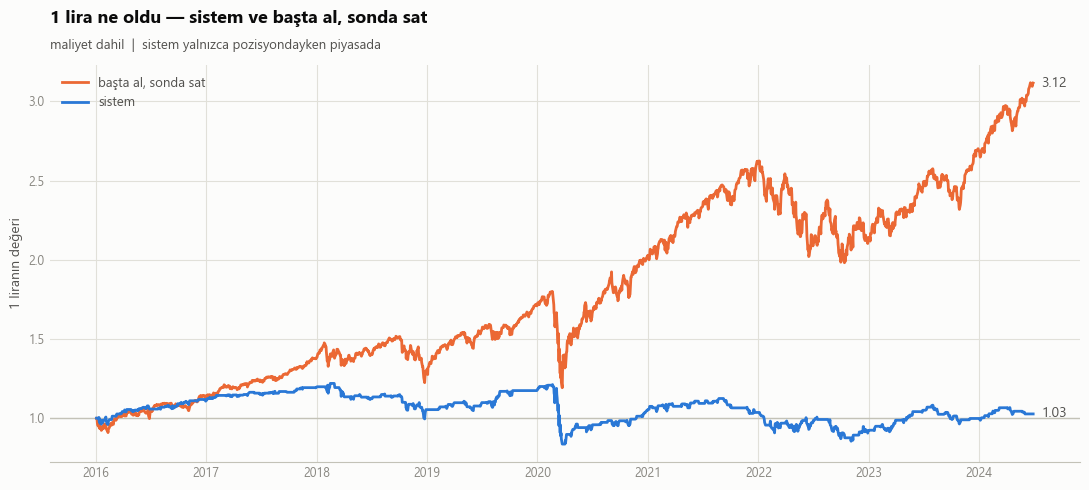

In [4]:
spy_g5, spy_s35 = calis(SPY_G, 5), calis(SPY_S, 35)
ozet_g, ozet_s = ozet(SPY_G, spy_g5, 252), ozet(SPY_S, spy_s35, 252 * 7)
display(pd.concat({'SPY günlük sistem': ozet_g['sistem'],
                   'SPY saatlik sistem': ozet_s['sistem'],
                   'başta al sonda sat': ozet_g['başta al, sonda sat']}, axis=1))
plots.equity_chart(SPY_G, spy_g5);

**Sonuç.** 1 lira → günlük **1.03**, saatlik **1.11**, hiçbir şey yapmayan
baseline **3.12**. İşlemlerin yaklaşık yarısı zararına satışla kapanıyor.

**Karar.** Sistem bu haliyle baseline'ın çok altında.

**Çıkarım.** İki şüphe doğdu: (1) eşikleri ben seçtim, belki kötü seçtim;
(2) belki sistem geçmişe uyduruluyor. İkisini de ölçmek gerek.

---
## Adım 3 — Eşikleri suçladık: 12 kombinasyonun hepsini denedik

**Ne denedik.** Alım payı (0.05 / 0.10 / 0.20) × zararına satış payı
(0.25 / 0.50 / 1.00). Tüm dönemde her birinin sonucu.

In [5]:
esik = [{'alım payı': a, 'zararına satış payı': s,
         'SPY günlük': lira(calis(SPY_G, 5, alim_payi=a, stop_payi=s)),
         'SPY saatlik': lira(calis(SPY_S, 35, alim_payi=a, stop_payi=s))}
        for a in (0.05, 0.10, 0.20) for s in (0.25, 0.50, 1.00)]
esik = pd.DataFrame(esik)
display(esik)
print(f"en iyi kombinasyon bile: günlük {esik['SPY günlük'].max():.2f}, "
      f"saatlik {esik['SPY saatlik'].max():.2f}  |  baseline 3.12")

,alım payı,zararına satış payı,SPY günlük,SPY saatlik
0,0.050,0.250,0.893,0.815
1,0.050,0.500,1.017,1.110
2,0.050,1.000,1.170,1.054
3,0.100,0.250,0.906,0.888
4,0.100,0.500,1.027,1.110
5,0.100,1.000,1.099,1.190
6,0.200,0.250,0.856,1.076
7,0.200,0.500,1.075,1.276
8,0.200,1.000,1.170,1.294


en iyi kombinasyon bile: günlük 1.17, saatlik 1.29  |  baseline 3.12


**Sonuç.** Hiçbir kombinasyon baseline'a yaklaşamadı. Zararına satış uzaklaştıkça
(0.25 → 1.00) sonuç **iyileşiyor**: zarar kesme kuralı para kaybettiriyor.

**Karar.** Sorun eşik seçimi değil.

**Çıkarım.** Sıradaki şüphe: sistem geçmişe uyduruluyor olabilir. Eşikleri
geçmişten seçip, hiç görülmemiş bir yılda denemek gerek.

---
## Adım 4 — Eğitim ve test: eşikleri geçmişten seç, gelecekte dene

**Ne denedik.** Her test yılı için eşikler **sadece o yıldan önceki** yıllarda
denenir, en iyisi seçilir ve o yılda uygulanır. 2019'dan 2024 Haziran'a kadar.
Bu, sistemin geçmişe uydurulup uydurulmadığını gösteren asıl testtir.

,test_yili,secilen_alim,secilen_stop,egitimde,testte,varsayilan_esiklerle,basta_al_sonda_sat
0,2019,0.050,2.000,0.173,0.088,0.118,0.310
1,2020,0.200,2.000,0.294,-0.062,-0.110,0.183
2,2021,0.050,2.000,0.273,0.198,-0.018,0.285
3,2022,0.050,2.000,0.525,-0.178,-0.113,-0.183
4,2023,0.050,2.000,0.254,0.030,0.080,0.260
5,2024,0.200,2.000,0.350,0.057,0.029,0.156


1 lira → günlük 1.09, saatlik 1.22, baseline 2.37


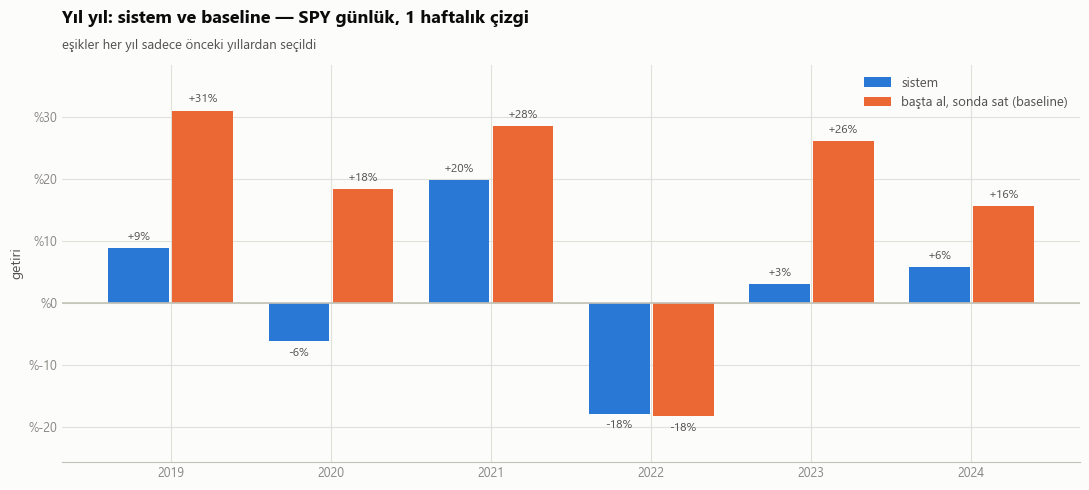

In [6]:
et_g = egitim_test(SPY_G, 5, TEST_YILLARI, maliyet=MALIYET)
et_s = egitim_test(SPY_S, 35, TEST_YILLARI, maliyet=MALIYET)
display(et_g)
print(f"1 lira → günlük {(1 + et_g['testte']).prod():.2f}, "
      f"saatlik {(1 + et_s['testte']).prod():.2f}, "
      f"baseline {(1 + et_g['basta_al_sonda_sat']).prod():.2f}")
plots.yearly_bars_chart(et_g['test_yili'], et_g['testte'], et_g['basta_al_sonda_sat'],
                        baslik='Yıl yıl: sistem ve baseline — SPY günlük, 1 haftalık çizgi',
                        alt_baslik='eşikler her yıl sadece önceki yıllardan seçildi');

**Sonuç.** 1 lira → günlük **1.09**, saatlik **1.22**, baseline **2.37**.
Eğitim her yıl **en uzak** zararına satış seviyesini seçti.

**Karar.** Sistem burada da baseline'ın altında.

**Çıkarım — önemli.** Sistemin eğitimdeki ve testteki yıllık getirisi birbirine
yakın (günlük %5.3 / %3.3). Yani **ezberleme yok**; sistem daha eğitim verisinde
bile baseline'ın gerisinde. Sorun eğitimde değil, kuralın kendisinde.
Sıradaki soru: belki çizgi süresi yanlıştır.

---
## Adım 5 — Çizgiyi kısalttık: 1, 2, 3, 5 günlük (saatlik veri)

**Ne denedik.** Kullanıcının isteği: "çizgiler daha kısa olsun, günlük dip ve
tepeye baksın." Saatlik veride 1 gün = 7 bar.

In [7]:
kisa = []
for gun in (1, 2, 3, 5):
    n = gun * 7
    s = calis(SPY_S, n)
    et = egitim_test(SPY_S, n, TEST_YILLARI, maliyet=MALIYET)
    kisa.append({'çizgi (gün)': gun, 'işlem': len(s.islemler), 'tüm dönem 1 lira →': lira(s),
                 'maliyet olmasa': float((1 + s.islemler['getiri']).prod()),
                 'eğitim/test 1 lira →': float((1 + et['testte']).prod())})
display(pd.DataFrame(kisa))
print('baseline: tüm dönem 3.12, eğitim/test 2.37')

,çizgi (gün),işlem,tüm dönem 1 lira →,maliyet olmasa,eğitim/test 1 lira →
0,1,1230,0.559,1.913,1.061
1,2,676,0.725,1.426,0.960
2,3,471,1.156,1.852,1.164
3,5,277,1.110,1.464,1.220


baseline: tüm dönem 3.12, eğitim/test 2.37


**Sonuç.** Çizgi kısaldıkça işlem sayısı patlıyor (1 günlük çizgide 1230 işlem)
ve kazancı maliyet yiyor: maliyetsiz 1.91 olan sonuç, maliyetle 0.56'ya düşüyor.
Hiçbiri baseline'a yaklaşmıyor.

**Karar.** Kısa çizgi işe yaramıyor.

**Çıkarım.** Ters yönü denemek gerek: çizgiler daha **uzun** olsun. Ayrıca
kullanıcının sorusu: seçtiğimiz dönem anormal mi?

---
## Adım 6 — Çizgiyi uzattık: 5, 10, 20, 50, 100 günlük (günlük veri)

**Ne denedik.** Uzun çizgide daha temiz bir kanal oluşur ve sistem düzgün
çalışır beklentisi. Ayrıca yıl yıl bakıp dönemin anormal olup olmadığını
kontrol ettik.

,çizgi (gün),işlem,piyasada,tüm dönem 1 lira →,eğitim/test 1 lira →
0,5,237,30%,1.026581,1.094461
1,10,121,31%,1.138491,1.148193
2,20,61,27%,1.211637,1.061319
3,50,21,23%,1.194582,1.196747
4,100,8,22%,1.126957,1.226958


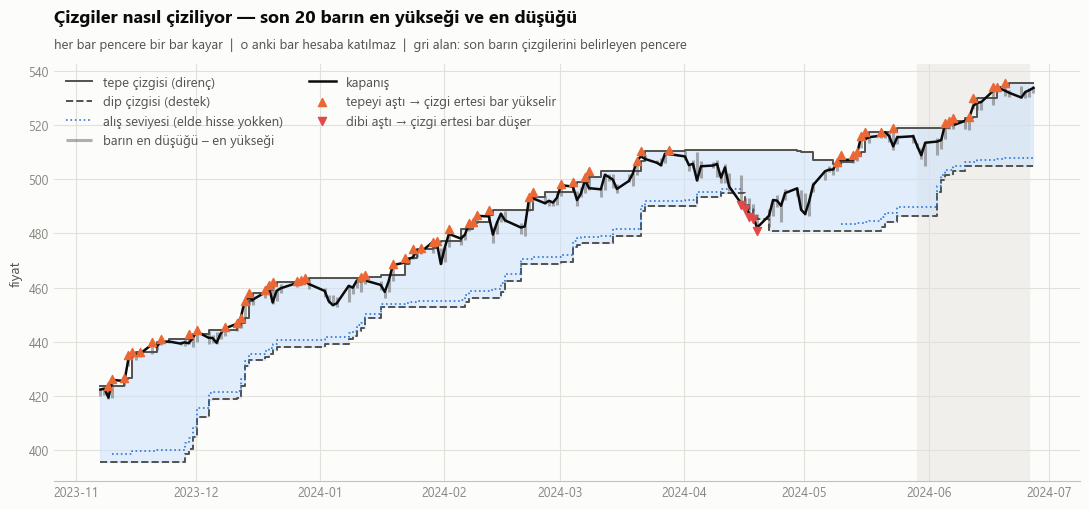

In [8]:
uzun = []
for gun in (5, 10, 20, 50, 100):
    s = calis(SPY_G, gun)
    et = egitim_test(SPY_G, gun, TEST_YILLARI, maliyet=MALIYET)
    piyasada = s.islemler['bar'].sum() / len(SPY_G) if len(s.islemler) else 0.0
    uzun.append({'çizgi (gün)': gun, 'işlem': len(s.islemler), 'piyasada': piyasada,
                 'tüm dönem 1 lira →': lira(s),
                 'eğitim/test 1 lira →': float((1 + et['testte']).prod())})
display(pd.DataFrame(uzun).style.format({'piyasada': '{:.0%}'}))
plots.lines_chart(SPY_G, calis(SPY_G, 20),
                  SPY_G['timestamp'].iloc[-160], SPY_G['timestamp'].iloc[-1]);

**Sonuç.** Uzun çizgide işlem çok azalıyor (100 günlükte 8 işlem) ve sistem
zamanın ~%75'inde nakitte oturuyor. Tüm dönemde en iyisi 1.21, baseline 3.12.

Grafikte asıl sorun görünüyor: **yükselişte fiyat tepe çizgisine yapışık
gidiyor, dibe hiç inmiyor.** "Dipte al" kuralı rallinin tamamını kaçırıyor.

**Dönem anormal mi?** SPY bu dönemde yılda ~%14 kazandırdı, uzun dönem
ortalaması ~%10. Dönem yükseliş yönünde cömert, ama sistem 9 yılın sadece
birinde (2022) baseline'ı geçti — yani sorun sadece dönem değil.

**Karar.** "Tepede sat" kuralıyla bu iş olmuyor (gözlem G-1).

**Çıkarım.** Kullanıcının teşhisi: sistem tepeye değince satıp çıkıyor ve
yükselişi kaçırıyor. İki değişiklik istendi: çizgiler daha hızlı güncellensin
(Bollinger) ve **tepede satmasın** (takip eden stop).

---
## Adım 7 — Sürüm 2: Bollinger bandı ve takip eden stop

**Ne denedik.** İki değişiklik, dört sürüm:

| | tepede sat | takip eden stop |
|---|---|---|
| **eski çizgi** (son 20 günün en yükseği/en düşüğü) | ilk sistem | yeni |
| **Bollinger** (20 günlük ortalama ± 2 sapma) | yeni | yeni |

**Takip eden stop:** fiyat tepeye değince satma. O andan sonra görülen en
yüksek fiyattan bir miktar düşerse sat. Seviye sadece yukarı gider.

Ayrıca kullanıcının kararı: **varlık tipine göre ayrı davranış**. SPY (fon) ve
AAPL (hisse) ayrı ayrı bakıldı. "Saf veri analizi bizi şaşırtıyor" — her tipin
kendi genel kabulü var (`REGISTRY.md` bölüm 1-2).

In [9]:
surumler = {'eski çizgi + tepede sat': dict(cizgi='donchian', satis='tepe'),
            'eski çizgi + takip eden stop': dict(cizgi='donchian', satis='takip'),
            'Bollinger + tepede sat': dict(cizgi='bollinger', satis='tepe'),
            'Bollinger + takip eden stop': dict(cizgi='bollinger', satis='takip')}
satir = []
for sembol, veri in (('SPY', SPY_G), ('AAPL', AAPL_G)):
    for ad, kural in surumler.items():
        s = calis(veri, 20, **kural)
        satir.append({'sembol': sembol, 'sürüm': ad, 'işlem': len(s.islemler),
                      'tüm dönem 1 lira →': lira(s),
                      'en büyük erime': bt.en_buyuk_dusus(s.bakiye),
                      'piyasada': s.islemler['bar'].sum() / len(veri)})
display(pd.DataFrame(satir).style.format({'en büyük erime': '{:.0%}', 'piyasada': '{:.0%}'}))
print('al-tut tüm dönem: SPY 3.12 (erime %34), AAPL 8.94 (erime %39)')

,sembol,sürüm,işlem,tüm dönem 1 lira →,en büyük erime,piyasada
0,SPY,eski çizgi + tepede sat,61,1.211637,-30%,27%
1,SPY,eski çizgi + takip eden stop,56,1.866989,-31%,58%
2,SPY,Bollinger + tepede sat,81,1.271142,-35%,36%
3,SPY,Bollinger + takip eden stop,75,2.196515,-32%,73%
4,AAPL,eski çizgi + tepede sat,52,0.802427,-53%,35%
5,AAPL,eski çizgi + takip eden stop,51,1.818506,-35%,56%
6,AAPL,Bollinger + tepede sat,70,0.875890,-42%,35%
7,AAPL,Bollinger + takip eden stop,68,2.127809,-38%,55%


al-tut tüm dönem: SPY 3.12 (erime %34), AAPL 8.94 (erime %39)


**Sonuç.** Takip eden stop sonucu belirgin iyileştirdi, Bollinger'ın katkısı
küçük. Ama iyileşmenin kaynağı şu: takip mesafesi genişledikçe sistem
**zamanın %90-98'inde piyasada kalıyor**, yani giderek baseline'a dönüşüyor.

**Karar.** Takip eden stop kalıcı oldu. SPY'da hâlâ baseline'ın altında.

**Çıkarım.** AAPL'da sonuç baseline'a çok yaklaştı. Asıl testi (eğitim/test)
görmek gerek.

---
## Adım 8 — İlk geçer not: AAPL, eski çizgi + takip eden stop (KABUL-1)

**Ne denedik.** Sürüm 2'yi eğitim/test düzeninde çalıştırdık: her yıl alım
payı, zararına satış payı ve takip mesafesi (36 kombinasyon) sadece önceki
yıllardan seçiliyor.

,test_yili,secilen_alim,secilen_stop,secilen_takip,egitimde,testte,varsayilan_esiklerle,basta_al_sonda_sat
0,2019,0.100,0.250,1.000,0.783,0.809,0.539,0.886
1,2020,0.100,2.000,1.000,2.290,0.927,-0.106,0.821
2,2021,0.100,2.000,1.000,5.642,0.203,0.033,0.345
3,2022,0.100,2.000,1.000,6.842,-0.208,-0.167,-0.265
4,2023,0.100,2.000,1.000,5.207,0.536,0.278,0.489
5,2024,0.100,2.000,1.000,8.430,0.138,0.186,0.114


AAPL günlük — sistem 5.80  baseline 5.66  | baseline'ı geçtiği yıl: 4/6


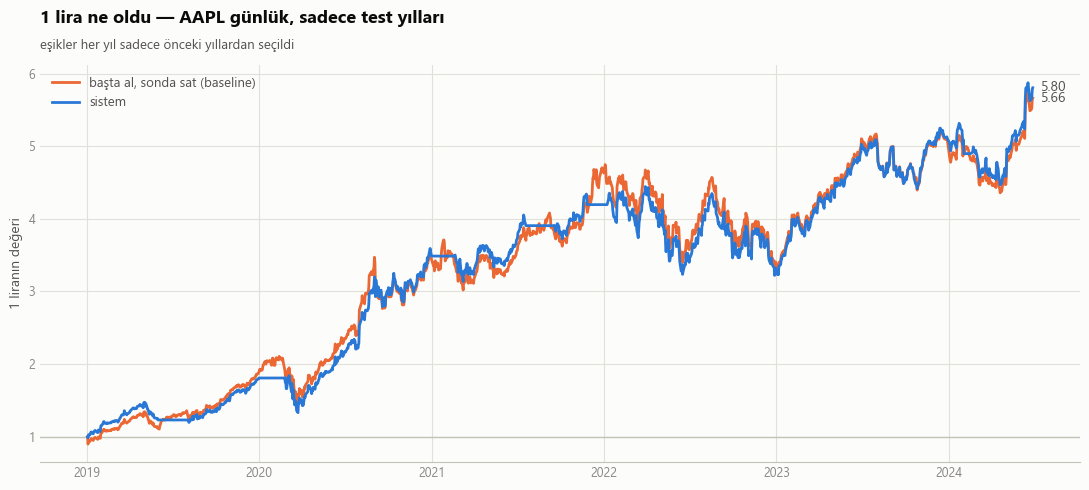

In [10]:
SABIT = dict(cizgi='donchian', satis='takip')
tablo, yil_sonuclari, _ = egitim_test_detay(AAPL_G, 20, TEST_YILLARI,
                                            maliyet=MALIYET, sabit=SABIT)
sistem = zincirle(yil_sonuclari, 20)
baseline = al_tut(AAPL_G, f'{TEST_YILLARI.start}-01-01', maliyet=MALIYET)
display(tablo)
print(f'AAPL günlük — sistem {sistem.iloc[-1]:.2f}  baseline {baseline.iloc[-1]:.2f}  '
      f"| baseline'ı geçtiği yıl: {(tablo['testte'] > tablo['basta_al_sonda_sat']).sum()}/6")
plots.compare_equity_chart(sistem, baseline,
                           baslik='1 lira ne oldu — AAPL günlük, sadece test yılları',
                           alt_baslik='eşikler her yıl sadece önceki yıllardan seçildi');

**Sonuç.** Test yıllarında 1 lira → **5.80**, baseline 5.66. Saatlikte 6.29
(kayıt: `REGISTRY.md` 6.8). Baseline'ı geçen ilk ve tek sistem.

**Karar: KABUL-1** — kullanıcı kararıyla, şimdilik, sınırları yazılı olarak.
Ayrıntılı dosya: `hypotheses/KABUL-1_AAPL_takip_eden_stop.md`.
Adım adım defteri: `KABUL-1_AAPL_takip_eden_stop.ipynb`.

**Sınırlar (kabulle birlikte yazıldı).** Sadece AAPL için. Fark küçük ve ~71
denemeden sonra geldi. Sistem zamanın ~%90'ında piyasada, yani kazancın çoğu
al-tut ile aynı kaynaktan geliyor. 8.5 yılda sadece 28 işlem. Önceden yazılmış
bir kabul kriteri yoktu.

**Çıkarım.** Kullanıcının teşhisi kayda geçti (H-002): "sorun seçilen hissede;
AAPL gibi hep yükselen hisselerde sistem al-tut'a dönüşüyor." Yatay seyreden
bir varlıkla henüz karşılaştırılmadı.

---
## Adım 9 — Denenip reddedilen değişiklik: zararına satış dip çizgisinde

**Ne denedik.** Kullanıcının isteği: "şu anda eğriyi biraz aşınca ne yapıyorsa
onu eğrinin üstüne gelince yapsın." KABUL-1'de alış ve takibe geçiş zaten
çizgide oluyor; çizginin ötesinde olan tek şey zararına satış. Onu **dip
çizgisinin kendisine** koyduk (`stop_payi = 0`), gerisi aynı.

,KABUL-1 (dibin altında),dip çizgisinde sat
1 lira →,5.804,3.563
işlem,22.000,90.000
zararına satılan,4.000,71.000
en büyük erime,-0.276,-0.350


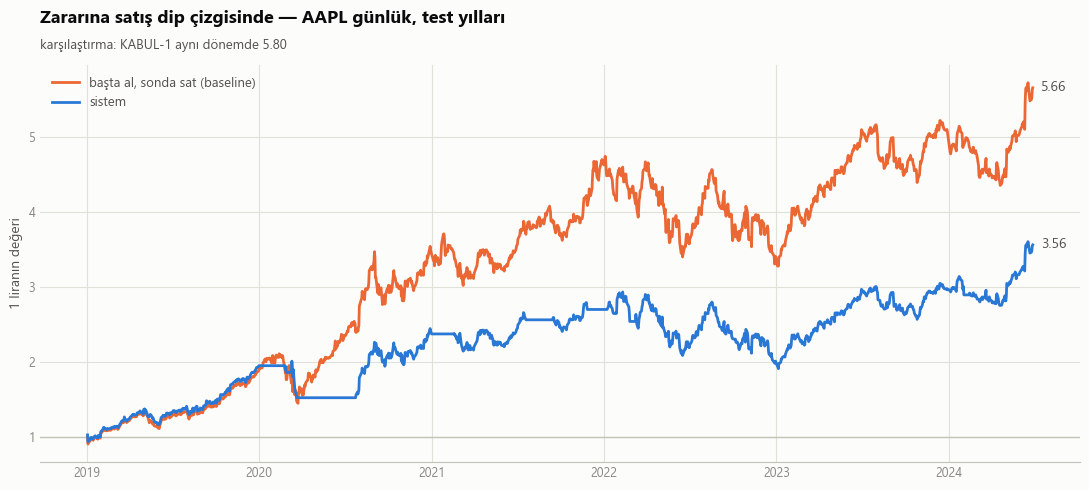

In [11]:
eski_secenekler = bt.STOP_SECENEKLERI
bt.STOP_SECENEKLERI = (0.0,)                 # sadece bu deneme için
t_dip, ys_dip, _ = egitim_test_detay(AAPL_G, 20, TEST_YILLARI, maliyet=MALIYET, sabit=SABIT)
bt.STOP_SECENEKLERI = eski_secenekler        # eski hale döndür

sistem_dip = zincirle(ys_dip, 20)
isl = pd.concat([s.islemler for s in ys_dip.values()])
isl_kabul = pd.concat([s.islemler for s in yil_sonuclari.values()])
display(pd.DataFrame({
    'KABUL-1 (dibin altında)': [sistem.iloc[-1], len(isl_kabul),
                                int((isl_kabul['sebep'] == 'stop').sum()),
                                bt.en_buyuk_dusus(sistem)],
    'dip çizgisinde sat': [sistem_dip.iloc[-1], len(isl),
                           int((isl['sebep'] == 'stop').sum()),
                           bt.en_buyuk_dusus(sistem_dip)],
}, index=['1 lira →', 'işlem', 'zararına satılan', 'en büyük erime']))
plots.compare_equity_chart(sistem_dip, baseline,
                           baslik='Zararına satış dip çizgisinde — AAPL günlük, test yılları',
                           alt_baslik='karşılaştırma: KABUL-1 aynı dönemde 5.80');

**Sonuç.** 1 lira → **3.56** (KABUL-1: 5.80). İşlem 22'den 90'a çıktı, 71'i
zararına satışla kapandı. Erime %35, KABUL-1'de %27.6. Saatlikte de kötü:
5.39'a karşı 6.29 (kayıt: `REGISTRY.md` 6.9).

**Karar.** Reddedildi, KABUL-1 aynen kaldı.

**Çıkarım.** AAPL dip çizgisine sık sık değip geri yükseliyor. Her değişte
satmak, küçük zararları toplamak demek.

---
## Adım 10 — Dakikalık veri

**Ne denedik.** Aynı sistem, kararlar her dakika. Çizgiler yine 20 gün, yani
7800 dakikalık bar. AAPL dakikalık veri indirildi (2016-01 → 2024-06,
1.5 milyon bar; saklanan dönemin dakikalık verisi hiç indirilmedi).

Hesap dakikalar sürdüğü için burada **kayıttan** gösteriliyor.
Kaynak: `REGISTRY.md` 6.10, hesabın kendisi
`KABUL-1_AAPL_takip_eden_stop.ipynb` adım 8b'de.

In [12]:
# kayıttan — REGISTRY.md 6.10
dakika = pd.DataFrame({
    'günlük': [5.804, 5.662, 22, 4, '27.6%'],
    'saatlik': [6.285, 5.634, 38, 19, '30.5%'],
    'dakikalık': [6.324, 5.567, 22, 3, '30.8%'],
}, index=['sistem 1 lira →', 'baseline 1 lira →', 'işlem', 'zararına satılan',
          'en büyük erime'])
display(dakika)

fark = pd.DataFrame({'günlük': ['-4.1%', '+1.4%', '-9.4%', '-2.6%', '+0.5%', '+2.5%'],
                     'saatlik': ['+9.7%', '+13.9%', '+2.3%', '+9.2%', '+9.7%', '+11.6%'],
                     'dakikalık': ['+9.7%', '+15.3%', '+2.3%', '+9.8%', '+11.0%', '+13.6%']},
                    index=[2019, 2020, 2021, 2022, 2023, 2024])
fark.index.name = 'yıl sonunda sistem baseline’dan % önde'
display(fark)

,günlük,saatlik,dakikalık
sistem 1 lira →,5.804,6.285,6.324
baseline 1 lira →,5.662,5.634,5.567
işlem,22,38,22
zararına satılan,4,19,3
en büyük erime,27.6%,30.5%,30.8%


,günlük,saatlik,dakikalık
yıl sonunda sistem baseline’dan % önde,,,
2019,-4.1%,+9.7%,+9.7%
2020,+1.4%,+13.9%,+15.3%
2021,-9.4%,+2.3%,+2.3%
2022,-2.6%,+9.2%,+9.8%
2023,+0.5%,+9.7%,+11.0%
2024,+2.5%,+11.6%,+13.6%


**Sonuç.** Dakikalık 6.32, saatlik 6.29, günlük 5.80. Dakikalık ile saatlik
neredeyse aynı. İşlem sayısı artmadı, yani maliyet sorun olmadı.

Baseline'dan farkın **ne zaman açıldığına** bakınca: saatlik ve dakikalıkta fark
daha ilk yıl açılıyor ve açık kalıyor; günlükte yıllarca eksi tarafta geziniyor,
ancak 2023-2024'te artıya geçiyor.

**Karar.** Dakikalığa geçmek belirgin kazanç getirmedi; KABUL-1 saatlik/günlük
haliyle kalıyor.

**Çıkarım.** Gün içi karar vermek faydalı, ama saatlikten ötesi fayda
getirmiyor. Asıl fark gün içinde işlem yapmakla yapmamak arasında.

---
## Nerede duruyoruz

| hipotez | iddia | durum |
|---|---|---|
| **H-001** | Fiyat kanal dibindeyken ertesi bar getirisi yüksektir | reddedildi (ölçüm eşiği geçmedi) |
| **H-001-B** | Kanal arasında al-sat, al-tut'u geçer | reddedildi (hiçbir ayarda geçmedi) |
| **H-001-C** | Bollinger + takip eden stop geçer | kararsız (SPY hayır, AAPL az farkla evet) |
| **KABUL-1** | AAPL, eski çizgi + takip eden stop | şimdilik kabul, sınırları yazılı |
| **H-002** | Sistem yatay seyreden varlıklarda çalışır | test edilmedi (veri yok) |
| **H-003** | SEC EDGAR açıklamaları ikinci karar mekanizması olur | test edilmedi |

**Deneme sayacı: ~74 ayar.** Bu sayı önemli: tamamen değersiz 50 strateji
denense bile aralarındaki en iyisi şans eseri iyi görünür. Bu yüzden
baseline'ı küçük farkla geçen bir sonuç, ek kanıt olmadan "çalışıyor"
sayılmıyor.

**Kalıcı gözlemler** (hepsi `REGISTRY.md` bölüm 3'te):
* Tepede satmak hiçbir ayarda kazandırmadı.
* Ezberleme görülmedi — sistem eğitim verisinde bile geride.
* Çizgi kısaldıkça maliyet kazancı yiyor; uzadıkça sistem nakitte oturuyor.
* Düşüşte belirgin koruma yok: erime baseline ile hemen hemen aynı.
* Kazanç, piyasada kalma süresiyle birlikte artıyor. Yani sistem iyileştikçe
  "al ve bekle"ye benziyor.

**Sıradakiler** (hiçbiri kullanıcı istemeden başlatılmaz):
1. KABUL-1'i aynı tipten 2+ hissede doğrulamak (MSFT, NVDA — veri indirilmeli).
2. H-002: yatay seyreden bir varlık tipi (altın, tahvil fonu) indirip denemek.
3. H-003: SEC EDGAR açıklamaları, 1-2 günlük ufuk.
4. Alım satım motoru: `docs/ALIM_SATIM_MOTORU.md` (motorun kodu henüz yok).

**Kasa (2024-07 → 2026-09) hiç açılmadı.** Bir kez açılacak, kullanıcının
kararıyla.